# TPI — Detección de Anemia mediante Frotis Sanguíneo
**Grupo 7** — Rosario Ballester Villafañe · Matilde Sanches Esteves Rosado · Agustín Rodriguez Torcelli  
Dataset: **AneRBC-II**

Pipeline:
1. Instalación de librerías y descarga del dataset
2. Carga de imágenes (AneRBC-II)
3. Pre-procesamiento
4. Segmentación de eritrocitos (Otsu + Watershed)
5. Extracción de características por célula
6. Agregación por imagen
7. Procesamiento del dataset de referencia (250 img/clase)
8. Módulo de validación con ground truth
9. Resumen estadístico por clase
10. Modelo de diagnóstico por centroides normalizados
    - Construcción del modelo de referencia
    - Validación del modelo
11. Diagnóstico de imagen nueva

# 1. INSTALACIÓN DE LIBRERÍAS Y DESCARGA DEL DATASET

In [4]:
!pip install kagglehub openpyxl -q

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

from scipy import ndimage as ndi

from skimage import filters, morphology, measure
from skimage.feature import graycomatrix, graycoprops, peak_local_max
from skimage.morphology import disk
from skimage.segmentation import watershed, clear_border

import kagglehub

print("Imports OK")

Imports OK


Se utilizará el dataset “AneRBC: Anemia Diagnosis Using RBC Images” disponible en Kaggle (https://www.kaggle.com/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images).

Está compuesto por **imágenes microscópicas de frotis sanguíneos** orientadas al análisis de eritrocitos para el estudio de anemia. La base se organiza en dos carpetas principales, AneRBC-I y AneRBC-II; dentro de cada una se encuentran carpetas correspondientes a individuos con anemia y a individuos sanos. En cada grupo se incluyen las imágenes originales del frotis, que fueron utilizadas como entrada para el posterior desarrollo del trabajo.

In [3]:
path = kagglehub.dataset_download(
    "jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images"
)
print("Dataset path:", path)

100%|██████████| 7.41G/7.41G [04:41<00:00, 28.2MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/versions/1


# 2. CARGA DE IMÁGENES — AneRBC-II

Se decidió utilizar la carpeta **AneRBC-II** con el objetivo de disminuir el costo computacional del procesamiento. Este conjunto contiene imágenes con mayor aumento, por lo que se observa un menor número de eritrocitos por imagen, reduciendo el tiempo requerido para la segmentación y extracción de características, sin comprometer la calidad visual necesaria para el análisis morfológico.

In [5]:
DATA_ROOT  = Path(path)
VALID_EXT  = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

matches = list(DATA_ROOT.rglob("AneRBC_dataset"))
if not matches:
    raise FileNotFoundError("No se encontró AneRBC_dataset dentro del path descargado.")
ANERBC_ROOT = matches[0]
print("AneRBC root:", ANERBC_ROOT)

image_paths = {"Anemic": [], "Healthy": []}

for group, label in [("Anemic_individuals", "Anemic"),
                     ("Healthy_individuals", "Healthy")]:
    folder = ANERBC_ROOT / "AneRBC-II" / group / "Original_images"
    if folder.exists():
        imgs = sorted([p for p in folder.rglob("*") if p.suffix.lower() in VALID_EXT])
        image_paths[label].extend(imgs)
        print(f"AneRBC-II — {label}: {len(imgs)} imágenes")
    else:
        print(f"  ADVERTENCIA: no existe {folder}")

print("\nTotal:")
for lbl, ps in image_paths.items():
    print(f"  {lbl}: {len(ps)} imágenes")

AneRBC root: /root/.cache/kagglehub/datasets/jocelyndumlao/anerbc-anemia-diagnosis-using-rbc-images/versions/1/AneRBC dataset a benchmark dataset for computer-aided anemia diagnosis using RBC images. httpsdoi.org10.1093databasebaae120/AneRBC_dataset
AneRBC-II — Anemic: 6000 imágenes
AneRBC-II — Healthy: 6000 imágenes

Total:
  Anemic: 6000 imágenes
  Healthy: 6000 imágenes


# 3. PRE-PROCESAMIENTO

El pipeline implementa dos ramas de pre-procesamiento con objetivos
distintos. Una orientada al análisis de características: `preprocess_for_analysis` y otra optimizada para la segmentación:
`preprocess_for_segmentatios`
Esta separación es una decisión de diseño deliberada, ya que los requisitos de contraste y suavizado difieren entre ambas tareas.

In [6]:
def preprocess_for_analysis(img_rgb):
    """
    Pre-procesamiento orientado al análisis de características:
    - Suavizado Gaussiano ligero para reducir ruido de alta frecuencia.
    - CLAHE sobre canal L (espacio LAB) para mejorar contraste local.
    """
    img = cv2.GaussianBlur(img_rgb.copy(), (5, 5), sigmaX=1)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def preprocess_for_segmentation(img_rgb):
    """
    Pre-procesamiento orientado a la segmentación:
    - CLAHE con clipLimit moderado para no saturar bordes celulares.
    - Escala de grises + filtro de mediana para suprimir ruido sal/pimienta.
    Retorna imagen mejorada (RGB) y mapa de grises filtrado.
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    L = clahe.apply(L)
    lab_enhanced = cv2.merge([L, A, B])
    img_enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)
    gray = cv2.cvtColor(img_enhanced, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 5)
    return img_enhanced, gray

# 4. SEGMENTACIÓN DE ERITROCITOS

El módulo implementa cuatro funciones que se encadenan en un pipeline de
segmentación completo.

Primero se implementa una función que convierte la imagen en escala de grises en una máscara binaria que distingue los objetos celulares del fondo:
`get_rbc_binary_mask`

Ya que es frecuente que los eritrocitos se toquen o superpongan. Se emplea una fucnión de 4 pasos que resuelve el problema mediante el algoritmo Watershed basado en transformada de distancia:
`split_touching_cells`

Tras el Watershed, el mapa de etiquetas puede contener regiones que no corresponden a eritrocitos reales. Esta función elimina esas
regiones:`filter_regions`





In [7]:
def get_rbc_binary_mask(gray, min_area=120, close_radius=2, remove_border=False):
    """
    Genera máscara binaria de eritrocitos candidatos mediante Otsu.
    Parámetros:
    - gray : ndarray  Imagen en escala de grises pre-filtrada.
    - min_area : int  Área mínima (px²) para conservar un objeto.
    - close_radius : int  Radio del disco de cierre morfológico.
    - remove_border : bool  Si True, elimina células tocando el borde.
    """
    thresh = filters.threshold_otsu(gray)
    binary = gray < thresh
    binary = morphology.binary_closing(binary, footprint=disk(close_radius))
    binary = ndi.binary_fill_holes(binary)
    binary = morphology.remove_small_objects(binary, min_size=min_area)
    binary = morphology.remove_small_holes(binary, area_threshold=min_area // 2)
    if remove_border:
        binary = clear_border(binary)
    return binary

def split_touching_cells(binary, min_distance=10, sigma=1.2):
    """
    Separa eritrocitos que se tocan usando transformada de distancia + Watershed.
    Parámetros:
    - min_distance : int  Distancia mínima entre máximos locales (px).
    - sigma : float       Suavizado de la transformada de distancia.
    """
    dist = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=sigma)

    coords = peak_local_max(
        dist_smooth,
        min_distance=min_distance,
        labels=binary,
        exclude_border=False
    )

    markers = np.zeros(binary.shape, dtype=np.int32)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i
    markers, _ = ndi.label(markers > 0)

    labels_ws = watershed(-dist_smooth, markers, mask=binary)
    return labels_ws, dist_smooth, markers


def filter_regions(labels,
                   min_area=80,
                   max_area=3000,
                   min_circularity=0.20,
                   min_solidity=0.60,
                   max_eccentricity=0.99):
    """
    Descarta objetos que no corresponden a eritrocitos típicos.
    Criterios de descarte:
    - Área fuera del rango [min_area, max_area].
    - Circularidad < min_circularity  (objetos demasiado irregulares).
    - Solidez < min_solidity          (objetos con indentaciones profundas).
    - Excentricidad > max_eccentricity (objetos muy alargados).
    """
    filtered  = np.zeros_like(labels, dtype=np.int32)
    new_label = 1

    for region in measure.regionprops(labels):
        area      = region.area
        perimeter = region.perimeter
        if perimeter == 0:
            continue

        circularity = 4 * np.pi * area / (perimeter ** 2)

        if area < min_area:
            continue
        if max_area is not None and area > max_area:
            continue
        if circularity < min_circularity:
            continue
        if region.solidity < min_solidity:
            continue
        if region.eccentricity > max_eccentricity:
            continue

        filtered[labels == region.label] = new_label
        new_label += 1

    regions = measure.regionprops(filtered)
    return filtered, regions

Integra las tres funciones anteriores y aplica el filtrado morfológico en dos niveles de permisividad diferentes:`segment_erythrocytes`



In [8]:
def segment_erythrocytes(img_rgb,
                         min_area_mask=80,
                         close_radius=2,
                         min_distance=10,
                         sigma=1.2,
                         remove_border=False):
    """
    Pipeline de segmentación de eritrocitos.

    Devuelve dos niveles de segmentación:
    - Permisivo (labels_count / regions_count): para conteo y densidad.
    - Estricto  (labels_features / regions_features): para extracción
      confiable de características morfológicas y de textura.

    Parámetros ajustados para AneRBC-II (mayor zoom, células más grandes).
    """
    img_enhanced, gray = preprocess_for_segmentation(img_rgb)

    binary = get_rbc_binary_mask(
        gray,
        min_area=min_area_mask,
        close_radius=close_radius,
        remove_border=remove_border
    )

    labels_ws, dist, markers = split_touching_cells(
        binary, min_distance=min_distance, sigma=sigma
    )

    # Filtrado permisivo: para conteo (max_area ampliado para AneRBC-II)
    labels_count, regions_count = filter_regions(
        labels_ws,
        min_area=100,
        max_area=5000,
        min_circularity=0.20,
        min_solidity=0.55,
        max_eccentricity=0.99
    )

    # Filtrado estricto: para features (parámetros calibrados para AneRBC-II)
    labels_features, regions_features = filter_regions(
        labels_ws,
        min_area=150,
        max_area=3500,
        min_circularity=0.45,
        min_solidity=0.75,
        max_eccentricity=0.97
    )

    return {
        "enhanced"        : img_enhanced,
        "gray"            : gray,
        "binary"          : binary,
        "dist"            : dist,
        "markers"         : markers,
        "labels_ws"       : labels_ws,
        "labels_count"    : labels_count,
        "regions_count"   : regions_count,
        "labels_features" : labels_features,
        "regions_features": regions_features
    }

# 5. EXTRACCIÓN DE CARACTERÍSTICAS POR CÉLULA

Una vez segmentados los eritrocitos, se extrae un vector de características para cada célula individualmente.
Estas características capturan distintas dimensiones de la apariencia celular con relevancia diagnóstica
conocida.
El módulo implementa tres funciones auxiliares especializadas:
`compute_circularity`
`compute_central_pallor`
`compute_glcm_features`

 y una función principal de extracción: `extract_cell_features`


In [9]:
def compute_circularity(area, perimeter):
    """
    Circularidad = 4π·A / P²
    Valor 1 → círculo perfecto. Valores menores → formas irregulares.
    """
    if perimeter == 0:
        return np.nan
    return 4 * np.pi * area / (perimeter ** 2)


def compute_central_pallor(gray_image, region_mask):
    """
    Estima el índice de palidez central (IPC) de un eritrocito.

    Método: comparación entre intensidad media de la zona central
    (obtenida por erosión morfológica) y la zona periférica.

    IPC > 1 → zona central más clara que periferia (palidez presente).
    IPC ≈ 1 → distribución uniforme de intensidad.

    Relevancia clínica: en anemia ferropénica los eritrocitos presentan
    mayor área de palidez central (IPC elevado).
    """
    region_mask = region_mask.astype(bool)
    if region_mask.sum() == 0:
        return np.nan

    central_mask = morphology.erosion(region_mask, disk(3))
    if central_mask.sum() == 0:
        return np.nan

    border_mask = region_mask & (~central_mask)
    if border_mask.sum() == 0:
        return np.nan

    central_mean = np.mean(gray_image[central_mask])
    border_mean  = np.mean(gray_image[border_mask])

    if border_mean == 0:
        return np.nan

    return central_mean / border_mean


def compute_glcm_features(gray_patch):
    """
    Características de textura mediante Matriz de Co-ocurrencia de Grises (GLCM).

    Niveles reducidos a 8 para robustez ante variaciones de iluminación.
    Ángulo único (0°, horizontal) con distancia 1 px.

    Retorna: contraste, homogeneidad, energía.
    """
    if gray_patch.size == 0:
        return np.nan, np.nan, np.nan
    patch = gray_patch.copy()
    if patch.max() == patch.min():
        return 0.0, 1.0, 1.0

    patch_norm = ((patch - patch.min()) / (patch.max() - patch.min()) * 7).astype(np.uint8)
    glcm = graycomatrix(
        patch_norm,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )
    contrast    = graycoprops(glcm, "contrast")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy      = graycoprops(glcm, "energy")[0, 0]
    return contrast, homogeneity, energy


def extract_cell_features(img_rgb_analysis, labels, regions):
    """
    Extrae características morfológicas, de intensidad, color, palidez
    central y textura de cada eritrocito segmentado.

    Entrada
    -------
    img_rgb_analysis : ndarray  Imagen RGB pre-procesada para análisis.
    labels           : ndarray  Mapa de etiquetas (segmentación estricta).
    regions          : list     Regiones de measure.regionprops(labels).

    Salida
    ------
    DataFrame con una fila por eritrocito y las siguientes columnas:
      Morfología : area, perimeter, circularity, eccentricity,
                   solidity, extent, orientation.
      Tamaño     : equivalent_diameter, major_axis_length,
                   minor_axis_length, aspect_ratio.
      Intensidad : mean_gray, std_gray.
      Color LAB  : mean_L, mean_A, mean_B_lab.
      Color RGB  : mean_R, mean_G, mean_B_rgb.
      Palidez    : central_pallor_index.
      Textura    : glcm_contrast, glcm_homogeneity, glcm_energy.
    """
    features = []
    gray = cv2.cvtColor(img_rgb_analysis, cv2.COLOR_RGB2GRAY)
    lab  = cv2.cvtColor(img_rgb_analysis, cv2.COLOR_RGB2LAB)

    for region in regions:
        label_id  = region.label
        cell_mask = labels == label_id

        area        = region.area
        perimeter   = region.perimeter
        circularity = compute_circularity(area, perimeter)
        aspect_ratio = (
            region.major_axis_length / region.minor_axis_length
            if region.minor_axis_length > 0 else np.nan
        )

        minr, minc, maxr, maxc = region.bbox
        gray_patch = gray[minr:maxr, minc:maxc]

        gray_vals  = gray[cell_mask]
        L_vals     = lab[:, :, 0][cell_mask]
        A_vals     = lab[:, :, 1][cell_mask]
        B_vals     = lab[:, :, 2][cell_mask]
        R_vals     = img_rgb_analysis[:, :, 0][cell_mask]
        G_vals     = img_rgb_analysis[:, :, 1][cell_mask]
        Br_vals    = img_rgb_analysis[:, :, 2][cell_mask]

        pallor_index = compute_central_pallor(gray, cell_mask)
        glcm_c, glcm_h, glcm_e = compute_glcm_features(gray_patch)

        features.append({
            # Morfología
            "label"              : label_id,
            "area"               : area,
            "perimeter"          : perimeter,
            "circularity"        : circularity,
            "eccentricity"       : region.eccentricity,
            "solidity"           : region.solidity,
            "extent"             : region.extent,
            "orientation"        : region.orientation,
            # Tamaño
            "equivalent_diameter": region.equivalent_diameter,
            "major_axis_length"  : region.major_axis_length,
            "minor_axis_length"  : region.minor_axis_length,
            "aspect_ratio"       : aspect_ratio,
            # Intensidad
            "mean_gray"          : np.mean(gray_vals),
            "std_gray"           : np.std(gray_vals),
            # Color LAB
            "mean_L"             : np.mean(L_vals),
            "mean_A"             : np.mean(A_vals),
            "mean_B_lab"         : np.mean(B_vals),
            # Color RGB
            "mean_R"             : np.mean(R_vals),
            "mean_G"             : np.mean(G_vals),
            "mean_B_rgb"         : np.mean(Br_vals),
            # Palidez central
            "central_pallor_index": pallor_index,
            # Textura
            "glcm_contrast"      : glcm_c,
            "glcm_homogeneity"   : glcm_h,
            "glcm_energy"        : glcm_e,
        })

    return pd.DataFrame(features)

#6. AGREGACIÓN DE CARACTERÍSTICAS POR IMAGEN

El clasificador opera a nivel de imagen, no a nivel de célula individual. Es necesario condensar el DataFrame de
células en un vector único que represente a toda la imagen. La función `aggregate_image_features` calcula
estadísticos descriptivos de la distribución de cada feature celular a lo largo de todos los eritrocitos de la imagen.

In [10]:
def aggregate_image_features(df_cells, rbc_count_candidates):
    """
    Agrega las características celulares a nivel de imagen.

    Por cada característica se calculan: media, desvío estándar,
    mediana, mínimo, máximo y coeficiente de variación (CV).
    El CV es especialmente útil para cuantificar anisocitosis y
    poiquilocitosis, hallazgos frecuentes en cuadros anémicos.

    Retorna diccionario con una fila por imagen.
    """
    summary = {
        "rbc_count_candidates": rbc_count_candidates,
        "n_cells_features"    : len(df_cells)
    }
    if len(df_cells) == 0:
        return summary

    selected_features = [
        "area", "perimeter", "circularity", "eccentricity",
        "solidity", "extent", "equivalent_diameter",
        "major_axis_length", "minor_axis_length", "aspect_ratio",
        "mean_gray", "std_gray",
        "mean_L", "mean_A", "mean_B_lab",
        "mean_R", "mean_G", "mean_B_rgb",
        "central_pallor_index",
        "glcm_contrast", "glcm_homogeneity", "glcm_energy"
    ]

    for feat in selected_features:
        if feat not in df_cells.columns:
            continue
        values = df_cells[feat].dropna()
        if len(values) == 0:
            continue
        m = values.mean()
        summary[f"{feat}_mean"]   = m
        summary[f"{feat}_std"]    = values.std()
        summary[f"{feat}_median"] = values.median()
        summary[f"{feat}_min"]    = values.min()
        summary[f"{feat}_max"]    = values.max()
        summary[f"{feat}_cv"]     = values.std() / m if m != 0 else np.nan

    return summary

# 7. PROCESAMIENTO DEL DATASET COMPLETO

Esta función itera sobre el diccionario de rutas de imágenes y aplica el pipeline completo (segmentación →
extracción → agregación) a cada imagen. Para el conjunto de referencia se procesan las primeras 250
imágenes por clase (N_REFERENCE_PER_CLASS = 250). El resultado es un DataFrame con una fila por
imagen y una columna por feature agregada, que se exporta a CSV y Excel.

In [22]:
def process_all_images_summary_only(image_paths, output_dir="./resultados"):
    """
    Procesa todas las imágenes de image_paths y devuelve un DataFrame
    con una fila por imagen (features agregadas).

    No acumula la tabla por célula para evitar uso excesivo de memoria.
    Imprime progreso cada 25 imágenes o al finalizar cada clase.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    all_features = []
    errors       = []

    for cls, paths in image_paths.items():
        print(f"\nClase: {cls} — {len(paths)} imágenes")

        for i, img_path in enumerate(paths):
            try:
                img_rgb = np.array(Image.open(img_path).convert("RGB"))

                result = segment_erythrocytes(img_rgb)

                img_analysis = preprocess_for_analysis(img_rgb)

                df_cells = extract_cell_features(
                    img_analysis,
                    result["labels_features"],
                    result["regions_features"]
                )

                image_summary = aggregate_image_features(
                    df_cells,
                    rbc_count_candidates=len(result["regions_count"])
                )

                image_summary["class"]              = cls
                image_summary["image_index"]        = i
                image_summary["image_path"]         = str(img_path)
                image_summary["n_regions_count"]    = len(result["regions_count"])
                image_summary["n_regions_features"] = len(result["regions_features"])
                image_summary["image_height"]       = img_rgb.shape[0]
                image_summary["image_width"]        = img_rgb.shape[1]

                all_features.append(image_summary)

                if (i + 1) % 25 == 0 or (i + 1) == len(paths):
                    print(f"  {i + 1}/{len(paths)} procesadas")

            except Exception as e:
                print(f"  Error en {img_path}: {e}")
                errors.append({
                    "class": cls, "image_index": i,
                    "image_path": str(img_path), "error": str(e)
                })

    return pd.DataFrame(all_features), pd.DataFrame(errors)

In [23]:
N_REFERENCE_PER_CLASS = 250

image_paths_ref = {
    cls: paths[:N_REFERENCE_PER_CLASS]
    for cls, paths in image_paths.items()
}

print("Subconjunto de referencia:")
for cls, ps in image_paths_ref.items():
    print(f"  {cls}: {len(ps)} imágenes")

df_reference, df_ref_errors = process_all_images_summary_only(
    image_paths=image_paths_ref,
    output_dir="./resultados_referencia"
)

print(f"\nReferencia: {df_reference.shape[0]} imágenes procesadas")
if len(df_ref_errors) > 0:
    print(f"Errores: {len(df_ref_errors)}")

# Guardar
REF_DIR = Path("./resultados_referencia")
REF_DIR.mkdir(exist_ok=True)
df_reference.to_csv(REF_DIR / "features_referencia.csv", index=False)
df_reference.to_excel(REF_DIR / "features_referencia.xlsx", index=False)
print("Referencia guardada en:", REF_DIR)

Subconjunto de referencia:
  Anemic: 250 imágenes
  Healthy: 250 imágenes

Clase: Anemic — 250 imágenes
  25/250 procesadas
  50/250 procesadas
  75/250 procesadas
  100/250 procesadas
  125/250 procesadas
  150/250 procesadas
  175/250 procesadas
  200/250 procesadas
  225/250 procesadas
  250/250 procesadas

Clase: Healthy — 250 imágenes
  25/250 procesadas
  50/250 procesadas
  75/250 procesadas
  100/250 procesadas
  125/250 procesadas
  150/250 procesadas
  175/250 procesadas
  200/250 procesadas
  225/250 procesadas
  250/250 procesadas

Referencia: 500 imágenes procesadas
Referencia guardada en: resultados_referencia


# 8. MÓDULO DE VALIDACIÓN CON GROUND TRUTH

La función evalúa el desempeño del clasificador utilizando un conjunto de validación independiente, compuesto por imágenes con etiqueta conocida que no fueron usadas para construir el modelo de referencia. Para ello, procesa 100 imágenes por clase a partir del índice posterior al conjunto de referencia, aplica el pipeline completo de segmentación y extracción de características, clasifica cada imagen y compara la predicción obtenida con la etiqueta real. Finalmente, calcula métricas de desempeño que permiten analizar la capacidad del sistema para diferenciar imágenes compatibles con patrón anémico y sano.

In [26]:
def validate_model(image_paths_all,
                   reference_model,
                   n_val_per_class=100,
                   offset=None,
                   output_dir="./resultados_validacion"):
    """
    Evalúa el modelo de diagnóstico sobre un conjunto de validación
    con etiquetas conocidas (ground truth).

    Parámetros
    ----------
    image_paths_all : dict   {clase: [Path, ...]} con TODAS las imágenes.
    reference_model : dict   Modelo construido con build_diagnostic_reference().
    n_val_per_class : int    Cantidad de imágenes a evaluar por clase.
    offset          : int    Índice de inicio (default: N_REFERENCE_PER_CLASS).
    output_dir      : str    Carpeta de salida para los resultados.

    Retorna
    -------
    df_results : DataFrame con predicción y ground truth por imagen.
    metrics    : dict con accuracy, precision, recall y F1.
    """
    if offset is None:
        offset = N_REFERENCE_PER_CLASS

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    results = []

    for true_class, paths in image_paths_all.items():
        val_paths = paths[offset: offset + n_val_per_class]
        print(f"\nValidando clase {true_class}: {len(val_paths)} imágenes")

        for i, img_path in enumerate(val_paths):
            try:
                img_rgb = np.array(Image.open(img_path).convert("RGB"))

                result = segment_erythrocytes(img_rgb)
                img_analysis = preprocess_for_analysis(img_rgb)

                df_cells = extract_cell_features(
                    img_analysis,
                    result["labels_features"],
                    result["regions_features"]
                )

                image_summary = aggregate_image_features(
                    df_cells,
                    rbc_count_candidates=len(result["regions_count"])
                )

                diagnosis = classify_image_summary(image_summary, reference_model)

                results.append({
                    "image_path"     : str(img_path),
                    "true_class"     : true_class,
                    "predicted_class": diagnosis["predicted_class"],
                    "score_anemic"   : diagnosis["score_anemic"],
                    "confidence"     : diagnosis["confidence"],
                    "correct"        : true_class == diagnosis["predicted_class"]
                })

                if (i + 1) % 10 == 0 or (i + 1) == len(val_paths):
                    print(f"  {i + 1}/{len(val_paths)} evaluadas")

            except Exception as e:
                print(f"  Error en {img_path}: {e}")
                results.append({
                    "image_path"     : str(img_path),
                    "true_class"     : true_class,
                    "predicted_class": "Error",
                    "score_anemic"   : np.nan,
                    "confidence"     : np.nan,
                    "correct"        : False
                })

    df_results = pd.DataFrame(results)

    # ── Métricas ──────────────────────────────────────────────
    n_total   = len(df_results)
    n_correct = df_results["correct"].sum()
    accuracy  = n_correct / n_total if n_total > 0 else 0.0

    # Métricas por clase (usando Anemic como positivo)
    tp = ((df_results["true_class"] == "Anemic") &
          (df_results["predicted_class"] == "Anemic")).sum()
    fp = ((df_results["true_class"] == "Healthy") &
          (df_results["predicted_class"] == "Anemic")).sum()
    fn = ((df_results["true_class"] == "Anemic") &
          (df_results["predicted_class"] == "Healthy")).sum()
    tn = ((df_results["true_class"] == "Healthy") &
          (df_results["predicted_class"] == "Healthy")).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "n_total"    : n_total,
        "n_correct"  : int(n_correct),
        "accuracy"   : round(accuracy, 4),
        "precision"  : round(precision, 4),   # exactitud para Anemic
        "recall"     : round(recall, 4),      # sensibilidad para Anemic
        "specificity": round(specificity, 4), # especificidad
        "f1_score"   : round(f1, 4),
        "tp": int(tp), "fp": int(fp),
        "fn": int(fn), "tn": int(tn)
    }

    # ── Imprimir resumen ──────────────────────────────────────
    print("\n" + "="*50)
    print("RESULTADOS DE VALIDACIÓN")
    print("="*50)
    print(f"  Total evaluadas : {n_total}")
    print(f"  Correctas       : {n_correct}  ({accuracy*100:.1f}%)")
    print(f"  Accuracy        : {accuracy:.4f}")
    print(f"  Precisión       : {precision:.4f}")
    print(f"  Sensibilidad    : {recall:.4f}")
    print(f"  Especificidad   : {specificity:.4f}")
    print(f"  F1-score        : {f1:.4f}")
    print()
    print("  Matriz de confusión (Anemic = positivo):")
    print(f"    TP={tp}  FP={fp}")
    print(f"    FN={fn}  TN={tn}")
    print("="*50)

    # ── Guardar ───────────────────────────────────────────────
    df_results.to_csv(output_dir / "validacion_predicciones.csv", index=False)
    df_results.to_excel(output_dir / "validacion_predicciones.xlsx", index=False)

    df_metrics = pd.DataFrame([metrics])
    df_metrics.to_csv(output_dir / "validacion_metricas.csv", index=False)
    df_metrics.to_excel(output_dir / "validacion_metricas.xlsx", index=False)

    print(f"\nResultados guardados en: {output_dir}")

    return df_results, metrics

#9. RESUMEN ESTADÍSTICO POR CLASE

Genera un DataFrame de resumen estadístico agrupado por clase (Anemic / Healthy) para todas las features
numéricas del dataset de referencia. Calcula media, desvío estándar, mediana, mínimo y máximo de cada
feature. El resultado se exporta a CSV y Excel con el prefijo indicado.

In [27]:
def generate_summary_by_class(df_images,
                               output_dir="./resultados",
                               filename_prefix="REF"):
    """
    Genera resumen estadístico (media, desvío, mediana, min, max)
    agrupado por clase, y lo guarda en CSV y Excel.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    numeric_cols = df_images.select_dtypes(include=[np.number]).columns
    exclude = {"image_index", "image_height", "image_width"}
    feature_cols = [c for c in numeric_cols if c not in exclude]

    df_summary = (
        df_images.groupby("class")[feature_cols]
        .agg(["mean", "std", "median", "min", "max"])
    )
    df_summary.columns = [f"{feat}_{stat}" for feat, stat in df_summary.columns]
    df_summary = df_summary.reset_index()

    csv_path   = output_dir / f"resumen_por_clase_{filename_prefix}.csv"
    excel_path = output_dir / f"resumen_por_clase_{filename_prefix}.xlsx"
    df_summary.to_csv(csv_path, index=False)
    df_summary.to_excel(excel_path, index=False)
    print(f"Resumen por clase guardado: {csv_path}")

    return df_summary


def compare_classes(df_images, class_col="class"):
    """
    Compara medias entre Anemic y Healthy para cada feature.
    Devuelve tabla con diferencia absoluta y relativa (%), ordenada
    por magnitud de diferencia relativa (features más discriminativas primero).
    """
    numeric_cols = df_images.select_dtypes(include=[np.number]).columns
    exclude      = {"image_index", "image_height", "image_width"}
    feature_cols = [c for c in numeric_cols if c not in exclude]

    means = df_images.groupby(class_col)[feature_cols].mean()

    comparison = pd.DataFrame({
        "mean_anemic" : means.loc["Anemic"],
        "mean_healthy": means.loc["Healthy"]
    })
    comparison["diff_anemic_minus_healthy"] = (
        comparison["mean_anemic"] - comparison["mean_healthy"]
    )
    comparison["relative_diff_%"] = (
        comparison["diff_anemic_minus_healthy"]
        / comparison["mean_healthy"].replace(0, np.nan)
    ) * 100

    return comparison.sort_values(
        by="relative_diff_%", key=lambda x: x.abs(), ascending=False
    )

#10. MODELO DE DIAGNÓSTICO POR CENTROIDES NORMALIZADOS

A partir del DataFrame de referencia (250 imágenes/clase), la función `build_diagnostic_reference` selecciona un subconjunto de features con
relevancia clínica conocida, normaliza el espacio de features mediante z-score global y calcula el centroide de
cada clase.
Para cada imagen de validación, la función aplica el pipeline completo y clasifica usando `classify_image_summary`. Luego compara la clase predicha con la etiqueta real y calcula distintas métricas.

In [28]:

def build_diagnostic_reference(df_reference, class_col="class"):
    """
    Construye el modelo de clasificación basado en centroides por clase.

    No emplea algoritmos de ML supervisado: el clasificador es la
    distancia euclídea en el espacio de features normalizado (z-score).
    Esto garantiza interpretabilidad y reproducibilidad, apropiadas
    para un trabajo práctico de nivel universitario.

    Features seleccionadas con base en relevancia clínica conocida:
    - Palidez central (hallazgo clásico en anemia ferropénica).
    - Variabilidad de tamaño y forma (anisocitosis y poiquilocitosis).
    - Intensidad media (correlaciona con contenido de hemoglobina).
    - Textura GLCM (diferencia células sanas de hipocrónicas).
    """
    candidate_features = [
        # Conteo / densidad
        "rbc_count_candidates", "n_cells_features",
        # Tamaño y variabilidad
        "area_mean", "area_cv",
        "equivalent_diameter_mean", "equivalent_diameter_cv",
        # Forma
        "circularity_mean", "circularity_cv",
        "eccentricity_mean",
        "solidity_mean", "solidity_std",
        "aspect_ratio_mean",
        # Intensidad / color
        "mean_gray_mean", "mean_L_mean",
        "mean_R_mean", "mean_G_mean", "mean_B_rgb_mean",
        # Palidez central (feature clave)
        "central_pallor_index_mean",
        # Textura
        "glcm_contrast_mean", "glcm_homogeneity_mean", "glcm_energy_mean",
    ]

    features = [f for f in candidate_features if f in df_reference.columns]
    if not features:
        raise ValueError("No se encontraron features válidas en df_reference.")

    available = set(df_reference[class_col].unique())
    if "Anemic" not in available or "Healthy" not in available:
        raise ValueError("df_reference debe contener las clases 'Anemic' y 'Healthy'.")

    df_model = df_reference[[class_col] + features].copy()
    for f in features:
        df_model[f] = df_model[f].fillna(df_model[f].mean())

    global_mean = df_model[features].mean()
    global_std  = df_model[features].std().replace(0, 1)

    df_z = df_model.copy()
    df_z[features] = (df_z[features] - global_mean) / global_std

    centroids = df_z.groupby(class_col)[features].mean()
    raw_means = df_model.groupby(class_col)[features].mean()

    return {
        "features"    : features,
        "class_col"   : class_col,
        "global_mean" : global_mean,
        "global_std"  : global_std,
        "centroids"   : centroids,
        "raw_means"   : raw_means
    }


def classify_image_summary(image_summary, reference_model):
    """
    Clasifica una imagen como Anemic o Healthy por distancia euclídea
    al centroide de cada clase en el espacio normalizado.

    Score anémico: fracción de la suma de distancias que corresponde
    a la distancia al centroide Healthy.
      score_anemic → 1: muy próximo a Anemic.
      score_anemic → 0: muy próximo a Healthy.

    Umbral de decisión ajustado:
    - Se aplica un sesgo conservador (threshold = 0.48) para reducir
      falsos positivos en casos sanos, corrigiendo la tendencia
      observada de clasificar frotis sanos como anémicos.
    """
    THRESHOLD = 0.48  # < 0.50 → requiere mayor evidencia anémica para clasificar

    features    = reference_model["features"]
    global_mean = reference_model["global_mean"]
    global_std  = reference_model["global_std"]
    centroids   = reference_model["centroids"]

    values = [
        image_summary.get(f, np.nan)
        if not pd.isna(image_summary.get(f, np.nan))
        else global_mean[f]
        for f in features
    ]
    x   = pd.Series(values, index=features)
    x_z = (x - global_mean[features]) / global_std[features]

    distances = {
        cls: np.sqrt(np.sum((x_z - centroids.loc[cls]) ** 2))
        for cls in centroids.index
    }

    d_anemic  = distances["Anemic"]
    d_healthy = distances["Healthy"]
    total     = d_anemic + d_healthy

    score_anemic = d_healthy / total if total > 0 else 0.5

    if score_anemic >= THRESHOLD:
        predicted_class = "Anemic"
        interpretation  = "Compatible con patrón anémico"
        confidence      = score_anemic
    else:
        predicted_class = "Healthy"
        interpretation  = "Compatible con patrón sano"
        confidence      = 1 - score_anemic

    return {
        "predicted_class"    : predicted_class,
        "interpretation"     : interpretation,
        "score_anemic"       : round(score_anemic, 4),
        "confidence"         : round(confidence, 4),
        "distance_to_anemic" : round(d_anemic, 4),
        "distance_to_healthy": round(d_healthy, 4)
    }

##CONSTRUCCIÓN DEL MODELO DE REFERENCIA

In [29]:

reference_model = build_diagnostic_reference(df_reference)
print("Modelo de referencia construido.")
print(f"Features utilizadas ({len(reference_model['features'])}):")
for f in reference_model["features"]:
    print(f"  - {f}")

# Resumen estadístico y comparación entre clases
df_ref_summary = generate_summary_by_class(
    df_reference, output_dir="./resultados_referencia", filename_prefix="REF"
)

comparison = compare_classes(df_reference)
print("\nTop 10 features más discriminativas:")
print(comparison.head(10).to_string())

comparison.to_csv("./resultados_referencia/comparacion_anemic_vs_healthy.csv")
comparison.to_excel("./resultados_referencia/comparacion_anemic_vs_healthy.xlsx")

Modelo de referencia construido.
Features utilizadas (21):
  - rbc_count_candidates
  - n_cells_features
  - area_mean
  - area_cv
  - equivalent_diameter_mean
  - equivalent_diameter_cv
  - circularity_mean
  - circularity_cv
  - eccentricity_mean
  - solidity_mean
  - solidity_std
  - aspect_ratio_mean
  - mean_gray_mean
  - mean_L_mean
  - mean_R_mean
  - mean_G_mean
  - mean_B_rgb_mean
  - central_pallor_index_mean
  - glcm_contrast_mean
  - glcm_homogeneity_mean
  - glcm_energy_mean
Resumen por clase guardado: resultados_referencia/resumen_por_clase_REF.csv

Top 10 features más discriminativas:
                      mean_anemic  mean_healthy  diff_anemic_minus_healthy  relative_diff_%
mean_A_cv                0.015176      0.010181                   0.004995        49.059501
mean_A_std               2.000622      1.376803                   0.623819        45.309240
mean_B_lab_std           2.169740      1.701048                   0.468692        27.553145
n_cells_features        8

## VALIDACIÓN DEL MODELO

In [30]:
N_VAL_PER_CLASS = 250  # imágenes de validación por clase

df_val_results, val_metrics = validate_model(
    image_paths_all=image_paths,
    reference_model=reference_model,
    n_val_per_class=N_VAL_PER_CLASS,
    output_dir="./resultados_validacion"
)


Validando clase Anemic: 250 imágenes
  10/250 evaluadas
  20/250 evaluadas
  30/250 evaluadas
  40/250 evaluadas
  50/250 evaluadas
  60/250 evaluadas
  70/250 evaluadas
  80/250 evaluadas
  90/250 evaluadas
  100/250 evaluadas
  110/250 evaluadas
  120/250 evaluadas
  130/250 evaluadas
  140/250 evaluadas
  150/250 evaluadas
  160/250 evaluadas
  170/250 evaluadas
  180/250 evaluadas
  190/250 evaluadas
  200/250 evaluadas
  210/250 evaluadas
  220/250 evaluadas
  230/250 evaluadas
  240/250 evaluadas
  250/250 evaluadas

Validando clase Healthy: 250 imágenes
  10/250 evaluadas
  20/250 evaluadas
  30/250 evaluadas
  40/250 evaluadas
  50/250 evaluadas
  60/250 evaluadas
  70/250 evaluadas
  80/250 evaluadas
  90/250 evaluadas
  100/250 evaluadas
  110/250 evaluadas
  120/250 evaluadas
  130/250 evaluadas
  140/250 evaluadas
  150/250 evaluadas
  160/250 evaluadas
  170/250 evaluadas
  180/250 evaluadas
  190/250 evaluadas
  200/250 evaluadas
  210/250 evaluadas
  220/250 evaluadas
 

## 12. DIAGNÓSTICO DE UNA IMAGEN NUEVA

Saving A1.png to A1.png
Imagen cargada: A1.png
────────────────────────────────────────────────
DIAGNÓSTICO DE IMAGEN
────────────────────────────────────────────────
  Clase predicha      : Anemic
  Interpretación      : Compatible con patrón anémico
  Score anémico       : 0.5883
  Confianza relativa  : 0.5883
  Distancia a Anemic  : 4.1850
  Distancia a Healthy : 5.9802
────────────────────────────────────────────────
  Candidatos (conteo) : 84
  Usados en features  : 81
────────────────────────────────────────────────
  Resultados en       : diagnostico

  AVISO: resultado computacional de apoyo.
  No reemplaza diagnóstico clínico.
────────────────────────────────────────────────


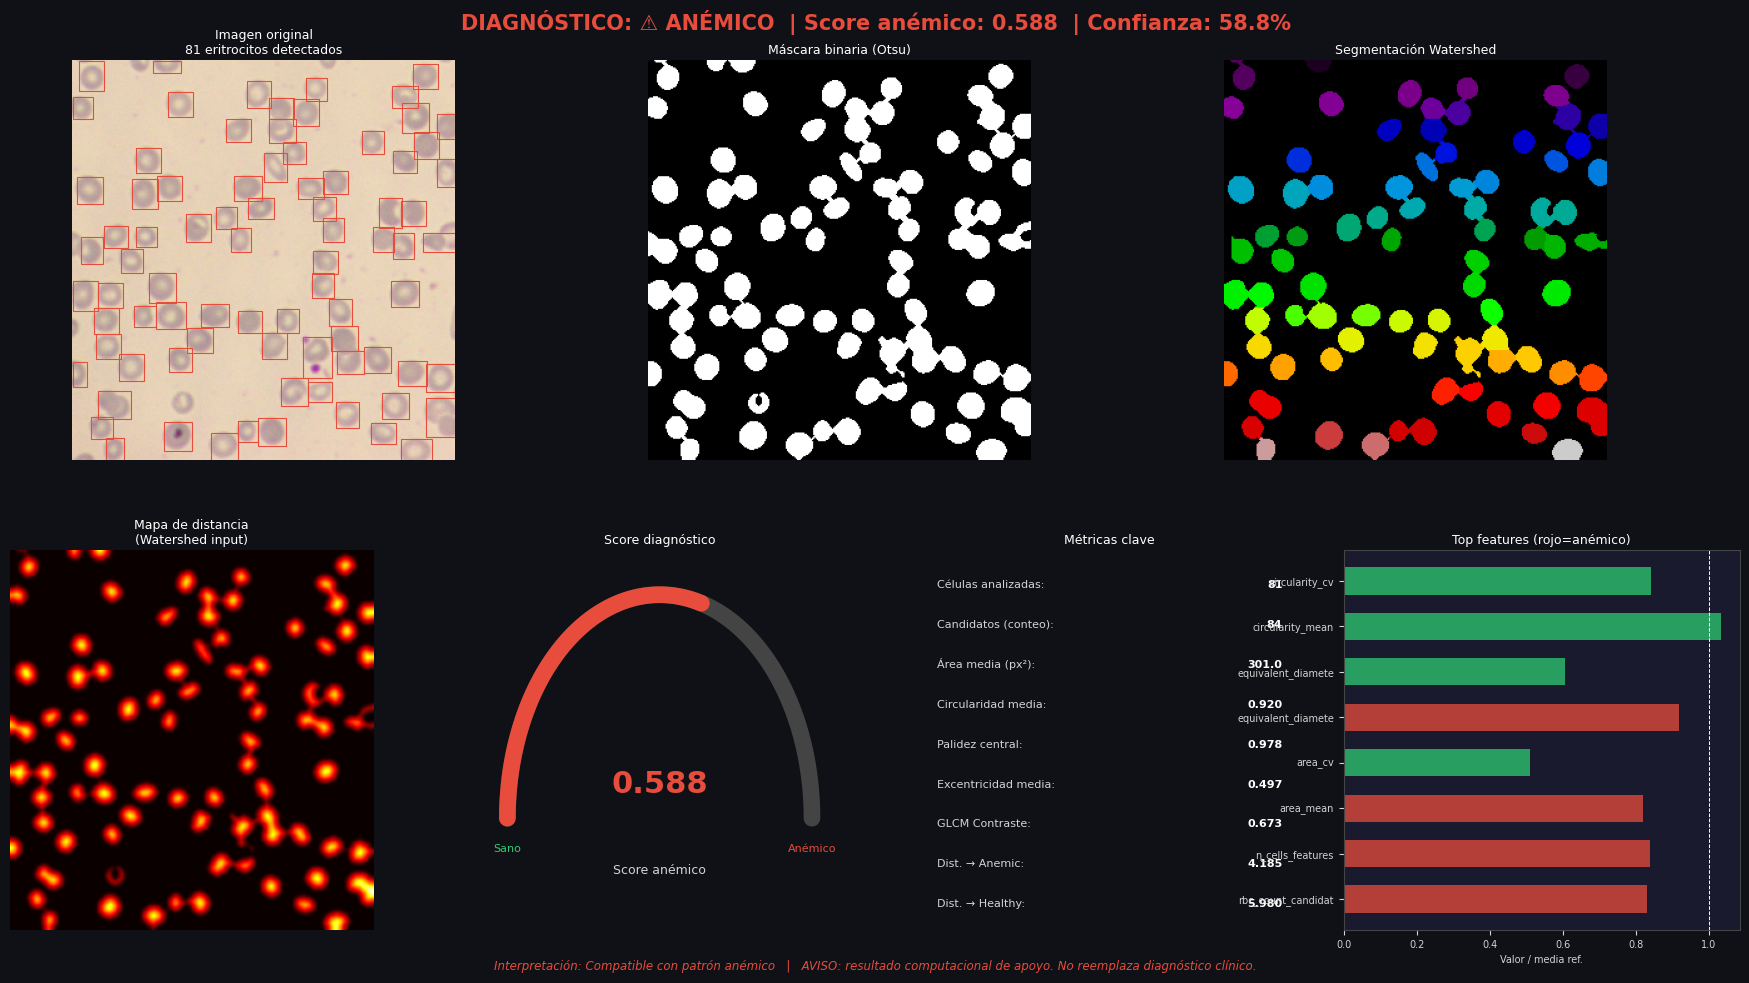

Figura guardada en: ./diagnostico/diagnostico_visual.png


In [31]:
def plot_diagnosis(img_rgb, result, diagnosis, image_summary, df_feature_report):
    """
    Visualización completa del diagnóstico en pantalla dentro del notebook.

    Panel superior  : imagen original | máscara binaria | Watershed coloreado
    Panel inferior  : mapa de distancia | score anémico (gauge) | top features
    """
    fig = plt.figure(figsize=(18, 10))
    fig.patch.set_facecolor("#0f1117")

    IS_ANEMIC = diagnosis["predicted_class"] == "Anemic"
    COLOR_DX   = "#e74c3c" if IS_ANEMIC else "#2ecc71"
    COLOR_BG   = "#1a1a2e"

    title_txt = (
        f"DIAGNÓSTICO: {'⚠ ANÉMICO' if IS_ANEMIC else '✓ SANO'}  "
        f"| Score anémico: {diagnosis['score_anemic']:.3f}  "
        f"| Confianza: {diagnosis['confidence']:.1%}"
    )
    fig.suptitle(title_txt, fontsize=15, fontweight="bold",
                 color=COLOR_DX, y=0.97)

    # Imagen original con contornos de eritrocitos
    ax1 = fig.add_axes([0.01, 0.52, 0.30, 0.40])
    ax1.imshow(img_rgb)
    from skimage import measure as _measure
    for region in _measure.regionprops(result["labels_features"]):
        minr, minc, maxr, maxc = region.bbox
        import matplotlib.patches as mpatches
        rect = mpatches.Rectangle(
            (minc, minr), maxc - minc, maxr - minr,
            linewidth=0.8, edgecolor=COLOR_DX, facecolor="none"
        )
        ax1.add_patch(rect)

    n_det = len(result["regions_features"])
    ax1.set_title(f"Imagen original\n{n_det} eritrocitos detectados",
                  color="white", fontsize=9, pad=4)
    ax1.axis("off")

    # Máscara binaria
    ax2 = fig.add_axes([0.33, 0.52, 0.30, 0.40])
    ax2.imshow(result["binary"], cmap="gray")
    ax2.set_title("Máscara binaria (Otsu)", color="white", fontsize=9, pad=4)
    ax2.axis("off")

    # Watershed coloreado
    ax3 = fig.add_axes([0.65, 0.52, 0.30, 0.40])
    ax3.imshow(result["labels_features"], cmap="nipy_spectral",
               vmin=0, vmax=max(result["labels_features"].max(), 1))
    ax3.set_title("Segmentación Watershed", color="white", fontsize=9, pad=4)
    ax3.axis("off")

    # Mapa de distancia
    ax4 = fig.add_axes([0.01, 0.05, 0.22, 0.38])
    ax4.imshow(result["dist"], cmap="hot")
    ax4.set_title("Mapa de distancia\n(Watershed input)",
                  color="white", fontsize=9, pad=4)
    ax4.axis("off")

    # Gauge de score anémico
    ax5 = fig.add_axes([0.27, 0.05, 0.22, 0.38])
    ax5.set_facecolor(COLOR_BG)
    import numpy as _np

    theta = _np.linspace(_np.pi, 0, 300)
    ax5.plot(_np.cos(theta), _np.sin(theta),
             color="#444", linewidth=12, solid_capstyle="round")

    score = diagnosis["score_anemic"]
    theta_score = _np.linspace(_np.pi, _np.pi - score * _np.pi, 300)
    ax5.plot(_np.cos(theta_score), _np.sin(theta_score),
             color=COLOR_DX, linewidth=12, solid_capstyle="round")

    ax5.text(0, 0.15, f"{score:.3f}", ha="center", va="center",
             fontsize=22, fontweight="bold", color=COLOR_DX)
    ax5.text(0, -0.25, "Score anémico", ha="center", fontsize=9, color="lightgray")
    ax5.text(-1.0, -0.15, "Sano", ha="center", fontsize=8, color="#2ecc71")
    ax5.text(1.0, -0.15, "Anémico", ha="center", fontsize=8, color="#e74c3c")
    ax5.set_xlim(-1.3, 1.3)
    ax5.set_ylim(-0.5, 1.2)
    ax5.axis("off")
    ax5.set_title("Score diagnóstico", color="white", fontsize=9, pad=4)

    # Panel de métricas clave
    ax6 = fig.add_axes([0.53, 0.05, 0.20, 0.38])
    ax6.set_facecolor(COLOR_BG)
    ax6.axis("off")

    metrics_lines = [
        ("Células analizadas", f"{int(image_summary.get('n_cells_features', 0))}"),
        ("Candidatos (conteo)", f"{int(image_summary.get('rbc_count_candidates', 0))}"),
        ("Área media (px²)",    f"{image_summary.get('area_mean', float('nan')):.1f}"),
        ("Circularidad media",  f"{image_summary.get('circularity_mean', float('nan')):.3f}"),
        ("Palidez central",     f"{image_summary.get('central_pallor_index_mean', float('nan')):.3f}"),
        ("Excentricidad media", f"{image_summary.get('eccentricity_mean', float('nan')):.3f}"),
        ("GLCM Contraste",      f"{image_summary.get('glcm_contrast_mean', float('nan')):.3f}"),
        ("Dist. → Anemic",      f"{diagnosis['distance_to_anemic']:.3f}"),
        ("Dist. → Healthy",     f"{diagnosis['distance_to_healthy']:.3f}"),
    ]

    ax6.set_title("Métricas clave", color="white", fontsize=9, pad=4)

    for k, (label, value) in enumerate(metrics_lines):
        y = 0.90 - k * 0.105
        ax6.text(0.02, y, label + ":", color="lightgray", fontsize=8,
                 transform=ax6.transAxes)
        ax6.text(0.98, y, value, color="white", fontsize=8,
                 fontweight="bold", ha="right", transform=ax6.transAxes)

    # Top features: valor vs referencia
    ax7 = fig.add_axes([0.76, 0.05, 0.22, 0.38])
    ax7.set_facecolor(COLOR_BG)

    df_top = df_feature_report.dropna(subset=["image_value"]).head(8).reset_index(drop=True)

    y_pos = _np.arange(len(df_top))
    bar_colors = ["#e74c3c" if c == "Anemic" else "#2ecc71"
                  for c in df_top["closer_to"]]

    vals = df_top["image_value"].values
    refs_a = df_top["mean_anemic_reference"].values
    refs_h = df_top["mean_healthy_reference"].values

    ref_avg = (refs_a + refs_h) / 2
    ref_avg[ref_avg == 0] = 1
    norm_vals = vals / ref_avg

    ax7.barh(y_pos, norm_vals, color=bar_colors, alpha=0.75, height=0.6)
    ax7.axvline(1.0, color="white", linewidth=0.7, linestyle="--")
    ax7.set_yticks(y_pos)

    short_names = [f[:18] for f in df_top["feature"]]
    ax7.set_yticklabels(short_names, fontsize=7, color="lightgray")
    ax7.set_xlabel("Valor / media ref.", color="lightgray", fontsize=7)
    ax7.tick_params(colors="lightgray", labelsize=7)
    ax7.set_facecolor(COLOR_BG)

    for spine in ax7.spines.values():
        spine.set_edgecolor("#444")

    ax7.set_title("Top features (rojo=anémico)", color="white", fontsize=9, pad=4)

    interp_color = "#e74c3c" if IS_ANEMIC else "#2ecc71"
    fig.text(
        0.5, 0.01,
        f"Interpretación: {diagnosis['interpretation']}   |   "
        "AVISO: resultado computacional de apoyo. No reemplaza diagnóstico clínico.",
        ha="center", fontsize=8.5, color=interp_color, style="italic"
    )

    plt.savefig("./diagnostico/diagnostico_visual.png",
                dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print("Figura guardada en: ./diagnostico/diagnostico_visual.png")


def diagnose_image_from_path(image_path, reference_model, output_dir="./diagnostico"):
    """
    Procesa una imagen nueva, realiza el diagnóstico y lo visualiza en pantalla.

    Retorna
    -------
    df_diagnosis      : DataFrame con features + diagnóstico.
    df_feature_report : Tabla comparativa feature a feature
                        (valor imagen vs. medias de referencia).

    AVISO: este módulo es una herramienta de apoyo computacional.
    No reemplaza el diagnóstico clínico ni hematológico.
    """
    import matplotlib

    matplotlib.rcParams.update({
        "axes.facecolor": "#1a1a2e",
        "figure.facecolor": "#0f1117",
        "text.color": "white",
        "xtick.color": "lightgray",
        "ytick.color": "lightgray",
        "axes.edgecolor": "#444",
        "axes.labelcolor": "lightgray",
    })

    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    img_rgb = np.array(Image.open(image_path).convert("RGB"))

    result = segment_erythrocytes(img_rgb)
    img_analysis = preprocess_for_analysis(img_rgb)

    df_cells = extract_cell_features(
        img_analysis,
        result["labels_features"],
        result["regions_features"]
    )

    image_summary = aggregate_image_features(
        df_cells,
        rbc_count_candidates=len(result["regions_count"])
    )

    image_summary["image_path"] = str(image_path)
    image_summary["n_regions_count"] = len(result["regions_count"])
    image_summary["n_regions_features"] = len(result["regions_features"])
    image_summary["image_height"] = img_rgb.shape[0]
    image_summary["image_width"] = img_rgb.shape[1]

    diagnosis = classify_image_summary(image_summary, reference_model)

    final_report = {**image_summary, **diagnosis}
    df_diagnosis = pd.DataFrame([final_report])

    raw_means = reference_model["raw_means"]
    feature_rows = []

    for f in reference_model["features"]:
        value = image_summary.get(f, np.nan)
        mean_anemic = raw_means.loc["Anemic", f]
        mean_healthy = raw_means.loc["Healthy", f]

        if pd.isna(value):
            closer_to = "No calculado"
        else:
            closer_to = (
                "Anemic"
                if abs(value - mean_anemic) < abs(value - mean_healthy)
                else "Healthy"
            )

        feature_rows.append({
            "feature": f,
            "image_value": value,
            "mean_anemic_reference": mean_anemic,
            "mean_healthy_reference": mean_healthy,
            "closer_to": closer_to
        })

    df_feature_report = pd.DataFrame(feature_rows)

    df_diagnosis.to_csv(output_dir / "diagnostico_imagen.csv", index=False)
    df_diagnosis.to_excel(output_dir / "diagnostico_imagen.xlsx", index=False)

    df_feature_report.to_csv(output_dir / "features_diagnostico_detalle.csv", index=False)
    df_feature_report.to_excel(output_dir / "features_diagnostico_detalle.xlsx", index=False)

    sep = "─" * 48
    print(sep)
    print("DIAGNÓSTICO DE IMAGEN")
    print(sep)
    print(f"  Clase predicha      : {diagnosis['predicted_class']}")
    print(f"  Interpretación      : {diagnosis['interpretation']}")
    print(f"  Score anémico       : {diagnosis['score_anemic']:.4f}")
    print(f"  Confianza relativa  : {diagnosis['confidence']:.4f}")
    print(f"  Distancia a Anemic  : {diagnosis['distance_to_anemic']:.4f}")
    print(f"  Distancia a Healthy : {diagnosis['distance_to_healthy']:.4f}")
    print(sep)
    print(f"  Candidatos (conteo) : {image_summary['rbc_count_candidates']}")
    print(f"  Usados en features  : {image_summary['n_cells_features']}")
    print(sep)
    print(f"  Resultados en       : {output_dir}")
    print()
    print("  AVISO: resultado computacional de apoyo.")
    print("  No reemplaza diagnóstico clínico.")
    print(sep)

    plot_diagnosis(img_rgb, result, diagnosis, image_summary, df_feature_report)

    return df_diagnosis, df_feature_report


def upload_and_diagnose_image(reference_model, output_dir="./diagnostico"):
    """
    Carga una imagen desde el entorno local en Google Colab
    y ejecuta el módulo de diagnóstico automático con visualización.
    """
    try:
        from google.colab import files
    except ImportError:
        raise ImportError("Esta función requiere Google Colab.")

    uploaded = files.upload()

    if not uploaded:
        raise ValueError("No se subió ninguna imagen.")

    image_path = list(uploaded.keys())[0]

    print(f"Imagen cargada: {image_path}")

    return diagnose_image_from_path(
        image_path=image_path,
        reference_model=reference_model,
        output_dir=output_dir
    )


# Ejecutar diagnóstico sobre imagen subida por el usuario
df_diagnosis, df_feature_report = upload_and_diagnose_image(
    reference_model=reference_model,
    output_dir="./diagnostico"
)